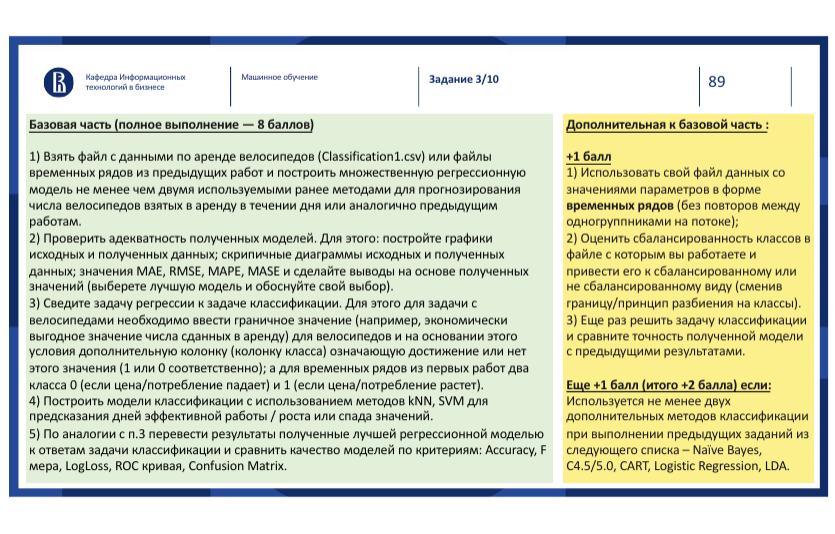

In [476]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, log_loss, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')



In [477]:

FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
N_LAGS = 5
TEST_SIZE = 0.2

df = pd.read_csv(FILEPATH)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors='coerce')
df = df.dropna(subset=[DATETIME_COL, VALUE_COL]).sort_values(DATETIME_COL)

agg = {VALUE_COL: 'sum'}
if 'units' in df.columns:
    agg['units'] = 'sum'
for col in ['unit_price', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']:
    if col in df.columns:
        agg[col] = 'mean'

df_ts = df.groupby(DATETIME_COL).agg(agg).reset_index().sort_values(DATETIME_COL)

y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values
units_full = df_ts['units'].values if 'units' in df_ts.columns else None

In [478]:

# ДАННЫЕ ДЛЯ SVR (x1 — индекс времени, x2 — units)
df_reg2 = pd.DataFrame({
    'y':  y_full,
    'x1': np.arange(len(y_full)),
    'x2': units_full,
}).dropna().reset_index(drop=True)

split_idx_2 = int(len(df_reg2) * 0.8)
train_2 = df_reg2.iloc[:split_idx_2]
test_2  = df_reg2.iloc[split_idx_2:]

X_train_2 = train_2[['x1', 'x2']].values
X_test_2  = test_2[['x1', 'x2']].values
y_train_2 = train_2['y'].values
y_test_2  = test_2['y'].values


# ДАННЫЕ ДЛЯ PLS (5 лагов)
df_lags = pd.DataFrame({'y': y_full})
for lag in range(1, 6):
    df_lags[f'lag_{lag}'] = df_lags['y'].shift(lag)
df_lags = df_lags.dropna().reset_index(drop=True)

feature_cols = [c for c in df_lags.columns if c != 'y']

split_idx_lasso = int(len(df_lags) * 0.8)
train_pls = df_lags.iloc[:split_idx_lasso]
test_pls  = df_lags.iloc[split_idx_lasso:]

X_train_pls = train_pls[feature_cols].values
y_train_pls = train_pls['y'].values
X_test_pls  = test_pls[feature_cols].values
y_test_pls  = test_pls['y'].values

print(f'PLS: train={len(X_train_pls)}, test={len(X_test_pls)}, features={len(feature_cols)}')
print(f'SVR: train={len(X_train_2)},   test={len(X_test_2)}')

PLS: train=246, test=62, features=5
SVR: train=250,   test=63


In [479]:


# --- Для SVR ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train_2)
X_test_s  = scaler_X.transform(X_test_2)

y_train_2_s = scaler_y.fit_transform(y_train_2.reshape(-1, 1)).ravel()

# --- Для PLS ---
scaler_pls = StandardScaler()
X_train_pls_s = scaler_pls.fit_transform(X_train_pls)
X_test_pls_s  = scaler_pls.transform(X_test_pls)

print('Масштабирование выполнено.')

Масштабирование выполнено.


In [480]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mase(y_true, y_pred, y_train, seasonality=1):
    naive = np.mean(np.abs(np.diff(y_train, n=seasonality))) if len(y_train) > seasonality \
            else np.mean(np.abs(y_train - np.mean(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive if naive else np.nan

reg_results = {}

svr2_model = SVR(kernel='linear', C=100.0, epsilon=0.05)
svr2_model.fit(X_train_s, y_train_2_s)

pred_svr2 = scaler_y.inverse_transform(
    svr2_model.predict(X_test_s).reshape(-1, 1)
).ravel()

m_svr2 = {
    'MAE':  mean_absolute_error(y_test_2, pred_svr2),
    'RMSE': np.sqrt(mean_squared_error(y_test_2, pred_svr2)),
    'MAPE': mape(y_test_2, pred_svr2),
    'MASE': mase(y_test_2, pred_svr2, y_train_2, seasonality=1),
    'R2':   r2_score(y_test_2, pred_svr2),
}
print(f"SVR (2 пар.)  MAE={m_svr2['MAE']:>12,.0f}  "
      f"RMSE={m_svr2['RMSE']:>12,.0f}  R²={m_svr2['R2']:.4f}, MAPE={m_svr2['MAPE']:>12,.0f}, MASE={m_svr2['MASE']:>4f}")

n_components = min(3, len(feature_cols))

pls_model = PLSRegression(n_components=n_components, scale=False)
pls_model.fit(X_train_pls_s, y_train_pls)
pred_pls = pls_model.predict(X_test_pls_s).ravel()

m_pls = {
    'MAE':  mean_absolute_error(y_test_pls, pred_pls),
    'RMSE': np.sqrt(mean_squared_error(y_test_pls, pred_pls)),
    'MAPE': mape(y_test_pls, pred_pls),
    'MASE': mase(y_test_pls, pred_pls, y_train_pls, seasonality=1),
    'R2':   r2_score(y_test_pls, pred_pls),
}
print(f"PLS (n_comp={n_components})  MAE={m_pls['MAE']:>12,.0f}  "
      f"RMSE={m_pls['RMSE']:>12,.0f}  R²={m_pls['R2']:.4f}, MAPE={m_pls['MAPE']:>12,.0f}%, MASE={m_pls['MASE']:>4f}")

SVR (2 пар.)  MAE=     100,088  RMSE=     112,238  R²=0.9872, MAPE=          10, MASE=0.641162
PLS (n_comp=3)  MAE=     114,249  RMSE=     155,302  R²=0.9758, MAPE=           7%, MASE=0.722255


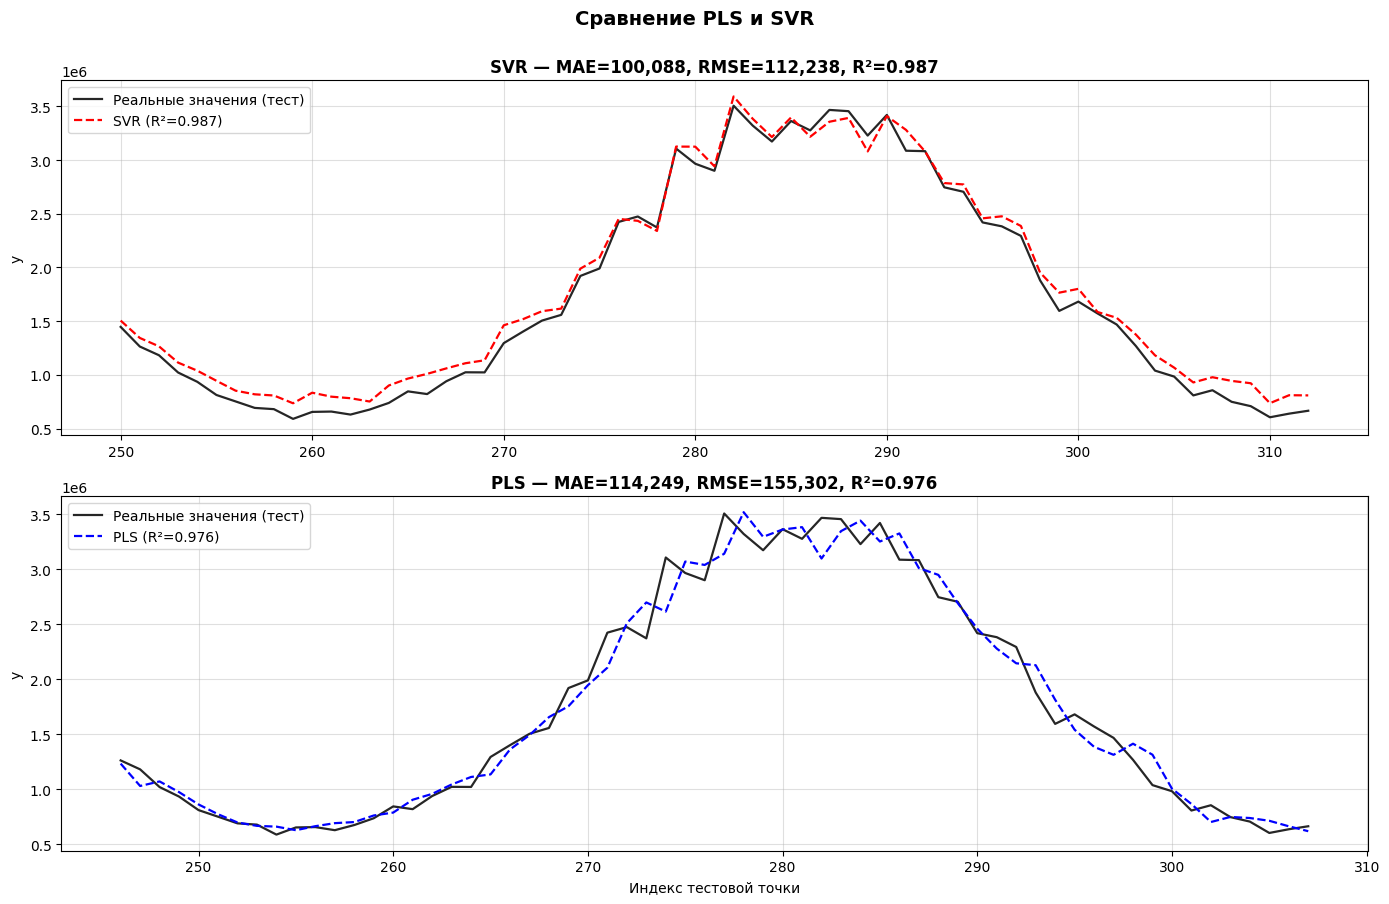

In [481]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# --- SVR ---
x_svr_idx = np.arange(split_idx_2, split_idx_2 + len(y_test_2))
axes[0].plot(x_svr_idx, y_test_2, 'k-', linewidth=1.6, alpha=0.85,
             label='Реальные значения (тест)')
axes[0].plot(x_svr_idx, pred_svr2, 'r--', linewidth=1.6,
             label=f"SVR (R²={m_svr2['R2']:.3f})")
axes[0].set_ylabel('y')
axes[0].set_title(
    f"SVR — MAE={m_svr2['MAE']:,.0f}, RMSE={m_svr2['RMSE']:,.0f}, R²={m_svr2['R2']:.3f}",
    fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.4)

# --- PLS ---
x_pls_idx = np.arange(split_idx_lasso, split_idx_lasso + len(y_test_pls))
axes[1].plot(x_pls_idx, y_test_pls, 'k-', linewidth=1.6, alpha=0.85,
             label='Реальные значения (тест)')
axes[1].plot(x_pls_idx, pred_pls, 'b--', linewidth=1.6,
             label=f"PLS (R²={m_pls['R2']:.3f})")
axes[1].set_xlabel('Индекс тестовой точки')
axes[1].set_ylabel('y')
axes[1].set_title(
    f"PLS — MAE={m_pls['MAE']:,.0f}, RMSE={m_pls['RMSE']:,.0f}, R²={m_pls['R2']:.3f}",
    fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.4)

fig.suptitle('Сравнение PLS и SVR', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

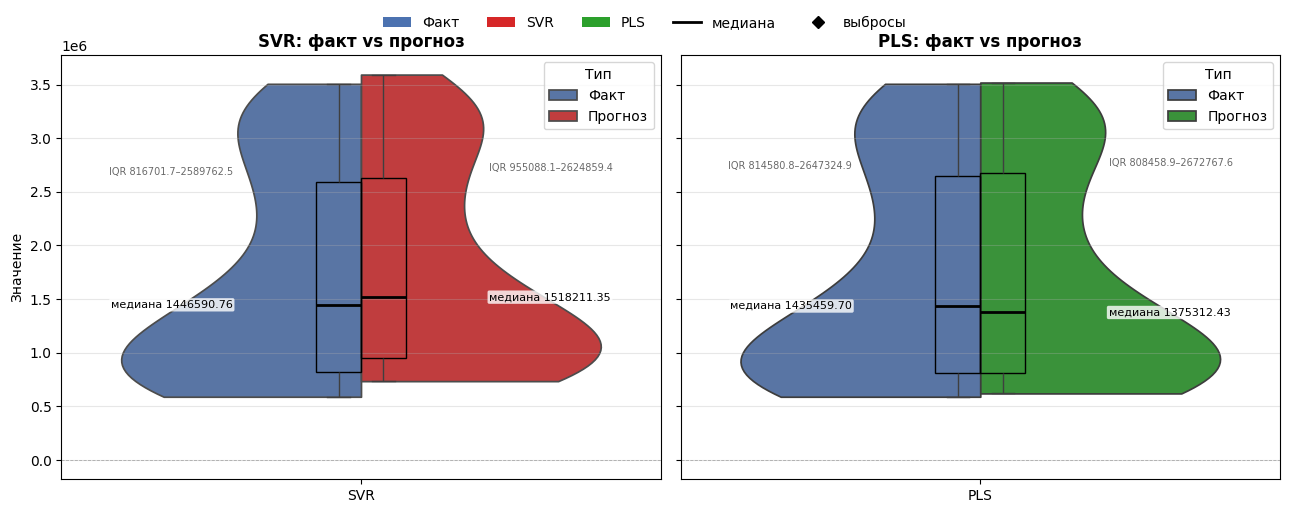

In [484]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

def draw(ax, fact, pred, title, color, name):
    df = pd.DataFrame({
        'Значение': np.r_[fact, pred],
        'Тип': ['Факт'] * len(fact) + ['Прогноз'] * len(pred),
    })

    sns.violinplot(data=df, x=[name] * len(df), y='Значение',
                   hue='Тип', split=True, inner=None, ax=ax,
                   palette=['#4c72b0', color], cut=0, density_norm='width')

    sns.boxplot(data=df, x=[name] * len(df), y='Значение',
                hue='Тип', ax=ax, width=0.15, dodge=True, legend=False,
                boxprops=dict(facecolor='none', edgecolor='black'),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='D', color='black', markersize=4))

    # подписи медиан
    for t, dx in [('Факт', -6), ('Прогноз', 6)]:
        v = df.loc[df['Тип'] == t, 'Значение']
        q1, med, q3 = v.quantile([.25, .5, .75])
        ax.annotate(f'медиана {med:.2f}', xy=(-0.2 if t == 'Факт' else 0.2, med),
                    xytext=(dx, 0), textcoords='offset points',
                    ha='left' if dx > 0 else 'right', va='center', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=.8))
        ax.annotate(f'IQR {q1:.1f}–{q3:.1f}', xy=(-0.2 if t == 'Факт' else 0.2, q3),
                    xytext=(dx, 4), textcoords='offset points',
                    ha='left' if dx > 0 else 'right', va='bottom', fontsize=7,
                    color='dimgray')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.axhline(0, color='grey', lw=.6, ls='--', alpha=.6)
    ax.grid(alpha=.3, axis='y')

draw(axes[0], y_test_2,   pred_svr2, 'SVR: факт vs прогноз', '#d62728', 'SVR')
draw(axes[1], y_test_pls, pred_pls,  'PLS: факт vs прогноз', '#2ca02c', 'PLS')

# компактная легенда
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
fig.legend(handles=[
    Patch(fc='#4c72b0', label='Факт'),
    Patch(fc='#d62728', label='SVR'),
    Patch(fc='#2ca02c', label='PLS'),
    Line2D([0], [0], color='black', lw=2, label='медиана'),
    Line2D([0], [0], marker='D', color='black', lw=0, label='выбросы'),
], loc='upper center', bbox_to_anchor=(.5, 1.03), ncol=5, frameon=False)

plt.tight_layout()
plt.show()

Часть с классификацией


In [ ]:
prev_test = df_lags['lag_1'].iloc[split_idx_lasso:].values
true_growth = (y_test_pls > prev_test).astype(int)
pred_growth = (pred_pls > prev_test).astype(int)

print('Баланс истинных классов:')
print(pd.Series(true_growth).value_counts(normalize=True).round(3))

Баланс истинных классов:
0    0.613
1    0.387
Name: proportion, dtype: float64


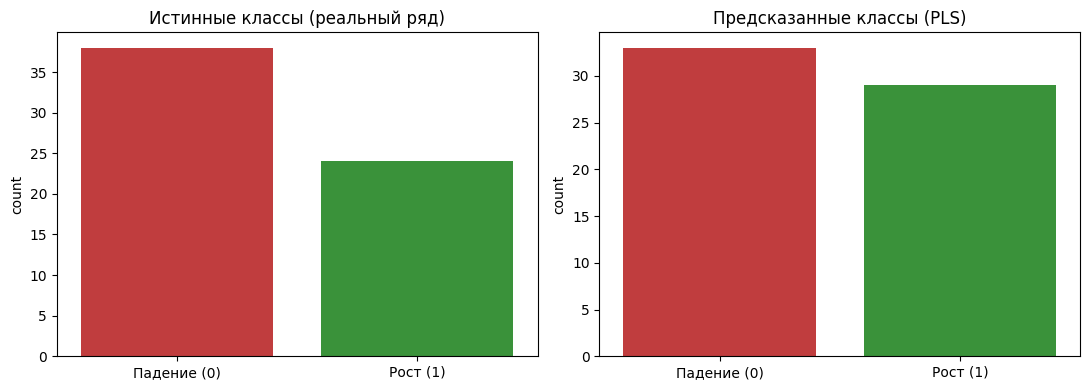

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x=true_growth, ax=axes[0], palette=['#d62728', '#2ca02c'])
axes[0].set_title('Истинные классы (реальный ряд)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Падение (0)', 'Рост (1)'])

sns.countplot(x=pred_growth, ax=axes[1], palette=['#d62728', '#2ca02c'])
axes[1].set_title('Предсказанные классы (PLS)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Падение (0)', 'Рост (1)'])

plt.tight_layout()
plt.show()

In [ ]:
cls_data = df_lags.copy()
cls_data['target'] = (cls_data['y'] > cls_data['lag_1']).astype(int)

# Делим так же, как PLS
train_c = cls_data.iloc[:split_idx_lasso].copy()
test_c  = cls_data.iloc[split_idx_lasso:].copy()

print('Баланс классов в train (до балансировки):')
print(train_c['target'].value_counts(normalize=True).round(3))
print('\nБаланс классов в test:')
print(test_c['target'].value_counts(normalize=True).round(3))

Баланс классов в train (до балансировки):
target
1    0.528
0    0.472
Name: proportion, dtype: float64

Баланс классов в test:
target
0    0.613
1    0.387
Name: proportion, dtype: float64


In [ ]:

from sklearn.utils import resample

def balance_binary(df, target_col='target', random_state=42):
    counts = df[target_col].value_counts()
    if len(counts) < 2:
        return df
    if counts.min() / counts.max() >= 0.8:
        print('Классы уже сбалансированы.')
        return df
    minority = df[df[target_col] == counts.idxmin()]
    majority = df[df[target_col] == counts.idxmax()]
    majority_down = resample(majority, replace=False,
                             n_samples=len(minority),
                             random_state=random_state)
    return (pd.concat([minority, majority_down])
              .sample(frac=1, random_state=random_state)
              .reset_index(drop=True))

train_c_bal = balance_binary(train_c)
print('\nПосле балансировки train:')
print(train_c_bal['target'].value_counts(normalize=True).round(3))

Xc_train = train_c_bal[feature_cols].values
yc_train = train_c_bal['target'].values
Xc_test  = test_c[feature_cols].values
yc_test  = test_c['target'].values

scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)

print(f'\nX train: {Xc_train_s.shape} | X test: {Xc_test_s.shape}')

Классы уже сбалансированы.

После балансировки train:
target
1    0.528
0    0.472
Name: proportion, dtype: float64

X train: (246, 5) | X test: (62, 5)


In [ ]:

pred_pls_cls = pred_growth

pred_pls_binary = (pred_pls > prev_test).astype(int) #КАЛ
prob_pls_cls = np.clip(pred_pls_cls, 0, 1)


res_pls_cls = {
    'pred': pred_pls_cls,
    'prob': prob_pls_cls,
    'y_true': yc_test,
    'Accuracy': accuracy_score(yc_test, pred_pls_cls),
    'F1': f1_score(yc_test, pred_pls_cls),
    'LogLoss': log_loss(yc_test, prob_pls_cls),
    'ROC-AUC': roc_auc_score(yc_test, prob_pls_cls),
    'CM': confusion_matrix(yc_test, pred_pls_cls),
}
from sklearn.preprocessing import MinMaxScaler
prob_pls = MinMaxScaler().fit_transform(pred_pls.reshape(-1, 1)).ravel()
res_pls_cls['ROC-AUC'] = roc_auc_score(true_growth, prob_pls)
print(f"{'PLS-Class':12s}  Acc={res_pls_cls['Accuracy']:.3f}  F1={res_pls_cls['F1']:.3f}  "
      f"LogLoss={res_pls_cls['LogLoss']:.3f}  ROC-AUC={res_pls_cls['ROC-AUC']:.3f}")

PLS-Class     Acc=0.790  F1=0.755  LogLoss=7.558  ROC-AUC=0.434


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, log_loss,
                             roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

def evaluate_clf(name, clf, X_tr, y_tr, X_te, y_te, threshold = 0.3):
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)[:, 1]

    pred = (prob >= threshold).astype(int)
    
    res = {
        'model':    clf,
        'pred':     pred,
        'prob':     prob,
        'y_true':   y_te,
        'Accuracy': accuracy_score(y_te, pred),
        'F1':       f1_score(y_te, pred),
        'LogLoss':  log_loss(y_te, prob),
        'ROC-AUC':  roc_auc_score(y_te, prob),
        'CM':       confusion_matrix(y_te, pred),
    }
    print(f"{name:12s}  Acc={res['Accuracy']:.3f}  F1={res['F1']:.3f}  "
          f"LogLoss={res['LogLoss']:.3f}  ROC-AUC={res['ROC-AUC']:.3f}")
    return res

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)

print('=== kNN и SVM на лагах (те же признаки, что у PLS) ===')
res_knn = evaluate_clf('kNN', knn, Xc_train_s, yc_train, Xc_test_s, yc_test)
res_svm = evaluate_clf('SVM', svm, Xc_train_s, yc_train, Xc_test_s, yc_test)

=== kNN и SVM на лагах (те же признаки, что у PLS) ===
kNN           Acc=0.629  F1=0.646  LogLoss=1.643  ROC-AUC=0.783
SVM           Acc=0.581  F1=0.629  LogLoss=0.545  ROC-AUC=0.828


In [ ]:

summary = pd.DataFrame({
    'kNN':       {'Accuracy': res_knn['Accuracy'],       'F1': res_knn['F1'],
                  'LogLoss':  res_knn['LogLoss'],        'ROC-AUC': res_knn['ROC-AUC']},
    'SVM':       {'Accuracy': res_svm['Accuracy'],       'F1': res_svm['F1'],
                  'LogLoss':  res_svm['LogLoss'],        'ROC-AUC': res_svm['ROC-AUC']},
    'PLS→Class': {'Accuracy': res_pls_cls['Accuracy'],   'F1': res_pls_cls['F1'],
                  'LogLoss':  res_pls_cls['LogLoss'],    'ROC-AUC': res_pls_cls['ROC-AUC']},
}).T

summary = summary[['Accuracy', 'F1', 'LogLoss', 'ROC-AUC']]
summary = summary.sort_values('F1', ascending=False)

print('=== Сравнение метрик: kNN, SVM, PLS→Class ===')
print(summary.round(4).to_string())
summary

=== Сравнение метрик: kNN, SVM, PLS→Class ===
           Accuracy      F1  LogLoss  ROC-AUC
PLS→Class    0.7903  0.7547   7.5575   0.4342
kNN          0.6290  0.6462   1.6430   0.7829
SVM          0.5806  0.6286   0.5448   0.8279


,Accuracy,F1,LogLoss,ROC-AUC
PLS→Class,0.790323,0.754717,7.557540,0.434211
kNN,0.629032,0.646154,1.642972,0.782895
SVM,0.580645,0.628571,0.544845,0.827851


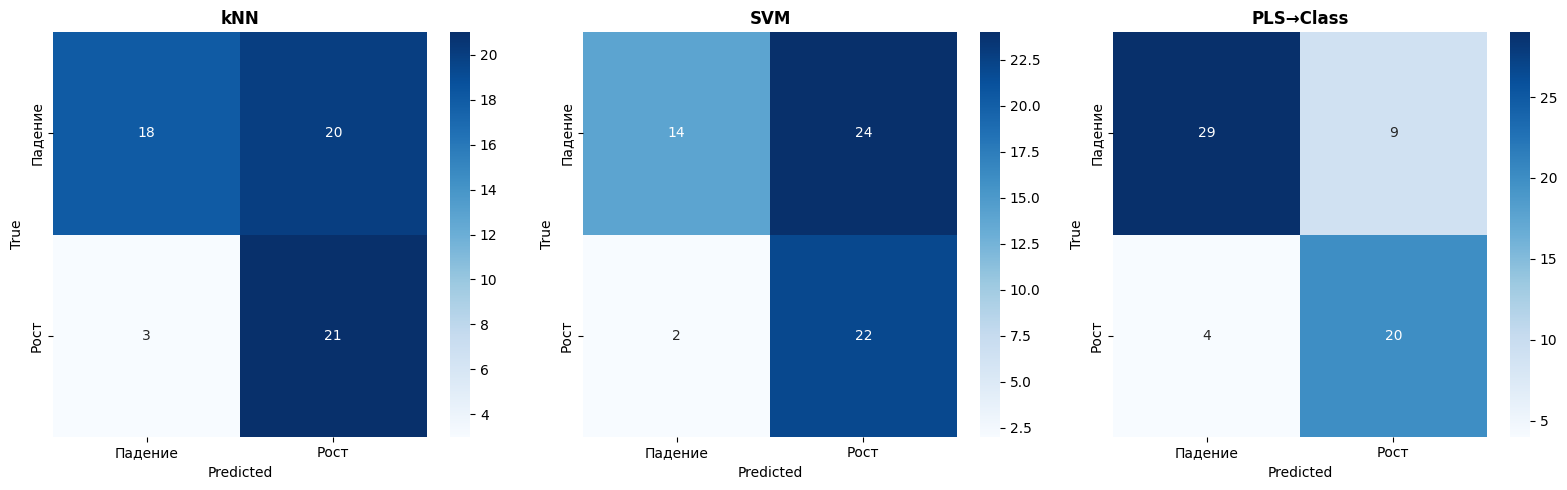

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

items = [
    (axes[0], res_knn['CM'],     'kNN'),
    (axes[1], res_svm['CM'],     'SVM'),
    (axes[2], res_pls_cls['CM'], 'PLS→Class'),
]

for ax, cm, name in items:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Падение', 'Рост'],
                yticklabels=['Падение', 'Рост'], ax=ax)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

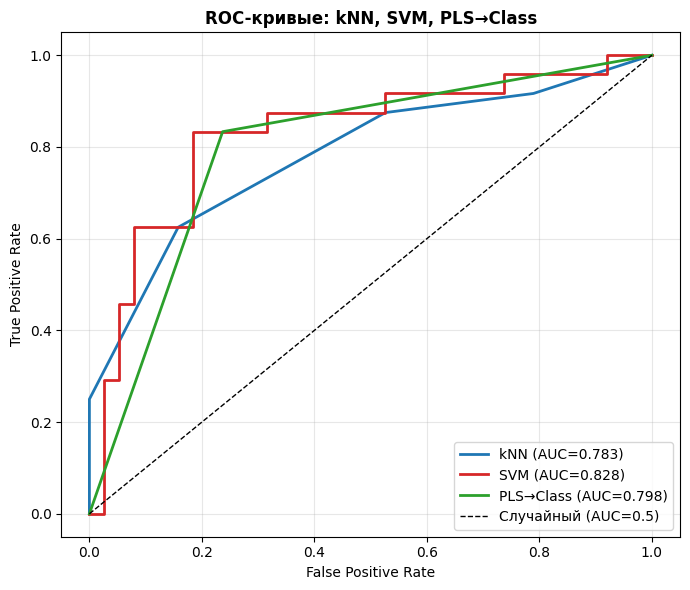

In [ ]:
plt.figure(figsize=(7, 6))

pairs = [
    (res_knn['y_true'],     res_knn['prob'],     'kNN',        '#1f77b4'),
    (res_svm['y_true'],     res_svm['prob'],     'SVM',        '#d62728'),
    (res_pls_cls['y_true'], res_pls_cls['prob'], 'PLS→Class',  '#2ca02c'),
]

for y_true, prob, name, color in pairs:
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: kNN, SVM, PLS→Class', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils import resample
import pandas as pd


def imbalance_by_majority(df, target_col='target',
                          keep_fraction=0.3, random_state=42):
    counts = df[target_col].value_counts()
    if len(counts) < 2:
        return df

    majority_label = counts.idxmax()
    minority_label = counts.idxmin()

    majority = df[df[target_col] == majority_label]
    minority = df[df[target_col] == minority_label]

    n_keep = max(1, int(len(majority) * keep_fraction))
    majority_down = resample(majority, replace=False,
                             n_samples=n_keep,
                             random_state=random_state)

    return (pd.concat([minority, majority_down])
              .sample(frac=1, random_state=random_state)
              .reset_index(drop=True))

In [ ]:
train_c_bal = imbalance_by_majority(train_c)
print('\nПосле балансировки train:')
print(train_c_bal['target'].value_counts(normalize=True).round(3))

Xc_train = train_c_bal[feature_cols].values
yc_train = train_c_bal['target'].values
Xc_test  = test_c[feature_cols].values
yc_test  = test_c['target'].values

scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)


После балансировки train:
target
0    0.748
1    0.252
Name: proportion, dtype: float64


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)

print('=== kNN и SVM на лагах (те же признаки, что у PLS) ===')
res_knn = evaluate_clf('kNN', knn, Xc_train_s, yc_train, Xc_test_s, yc_test,0.45)
res_svm = evaluate_clf('SVM', svm, Xc_train_s, yc_train, Xc_test_s, yc_test,0.45)

=== kNN и SVM на лагах (те же признаки, что у PLS) ===
kNN           Acc=0.726  F1=0.541  LogLoss=2.126  ROC-AUC=0.796
SVM           Acc=0.742  F1=0.556  LogLoss=0.565  ROC-AUC=0.787


In [ ]:

summary2 = pd.DataFrame({
    'kNN':       {'Accuracy': res_knn['Accuracy'],       'F1': res_knn['F1'],
                  'LogLoss':  res_knn['LogLoss'],        'ROC-AUC': res_knn['ROC-AUC']},
    'SVM':       {'Accuracy': res_svm['Accuracy'],       'F1': res_svm['F1'],
                  'LogLoss':  res_svm['LogLoss'],        'ROC-AUC': res_svm['ROC-AUC']}
}).T

summary2 = summary2[['Accuracy', 'F1', 'LogLoss', 'ROC-AUC']]
summary2 = summary2.sort_values('F1', ascending=False)

print('=== Сравнение метрик: kNN, SVM (Дисбаланс)===')
print(summary2.round(4).to_string())
summary = summary.drop("PLS→Class")
print('=== Сравнение метрик: kNN, SVM (Баланс)===')
print(summary.round(4).to_string())

=== Сравнение метрик: kNN, SVM (Дисбаланс)===
     Accuracy      F1  LogLoss  ROC-AUC
SVM    0.7419  0.5556   0.5654   0.7873
kNN    0.7258  0.5405   2.1264   0.7961
=== Сравнение метрик: kNN, SVM (Баланс)===
     Accuracy      F1  LogLoss  ROC-AUC
kNN    0.6290  0.6462   1.6430   0.7829
SVM    0.5806  0.6286   0.5448   0.8279
